# Image Classification with CNNs

## Start with the problem we want to solve

Imagine reading a handwritten digit from a small grayscale image. The input is a grid of pixel intensities; the answer is one class from zero through nine. A handwritten two can look different across examples, so memorizing one exact pixel pattern is not enough.

A convolutional neural network (CNN) is an artificial neural network whose shared filters can learn useful local patterns across image positions. Later layers combine those responses into evidence for each class. We supply labeled images and a loss; training adjusts the filters and classifier together. The network does not receive a verbal definition of each digit.

This project uses the handwritten-digit images bundled with scikit-learn: 1,797 grayscale images, each 8 × 8 pixels, with intensities from zero to 16. It runs on CPU without dataset downloads. We train a small CNN, compare it to logistic regression on flattened pixels, and inspect held-out mistakes. This is classification of already cropped digits, not detection of text in a full photograph.

Read the [companion notes](17_Image_Classification_with_CNNs_Notes.ipynb) for the illustrated walkthrough. The small hand-chosen example below explains the mechanics; its three-class model is separate from the ten-class model trained on the dataset.

In [1]:
import copy
import tempfile
from pathlib import Path
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

torch.manual_seed(15)
torch.set_num_threads(1)
np.random.seed(15)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('CPU | bundled 8 × 8 digit images | fixed seeds')

CPU | bundled 8 × 8 digit images | fixed seeds


## Follow a complete miniature prediction before training

Use this deliberately simple image and filter, with no convolution bias:

$$X=\begin{bmatrix}0&1&0\\0&1&0\\0&1&0\end{bmatrix},\qquad K=\begin{bmatrix}0&1\\0&1\end{bmatrix}.$$

The upper-left patch gives $0(0)+1(1)+0(0)+1(1)=2$. The upper-right patch gives $1(0)+0(1)+1(0)+0(1)=0$. The lower two patches repeat these calculations. The feature map is $[[2,0],[2,0]]$; ReLU leaves it unchanged, and global averaging gives $s=(2+0+2+0)/4=1$.

For this teaching example only, use three possible labels, zero, one, and two. The head has weights $[-1,2,0]$ and zero biases. Multiplying each weight by $s=1$ gives logits $[-1,2,0]$. Softmax can subtract the largest logit before exponentiating without changing the result:

$$e^{[-3,0,-2]}\approx[0.049787,1,0.135335],$$

whose sum is $1.185122$. Divide each entry by that sum to get probabilities approximately $[0.042010,0.843795,0.114195]$. The largest probability selects digit one. With true label one, cross-entropy is $-\ln(0.843795)\approx0.169846$.

The filter responds strongly to the vertical bright pixels, and the head associates a larger response with class one because we chose those weights. A trained model must learn such useful associations from many examples. This miniature does not demonstrate reliable recognition of zeros or twos.

## See how a correct but uncertain answer still teaches the filters

Cross-entropy uses probability, not only whether the largest score has the right label. For the miniature, the logit derivatives are probabilities minus the one-hot target $[0,1,0]$:

$$d=[0.042010,-0.156205,0.114195].$$

Each head weight multiplies $s=1$, so its gradient is $d_i(1)=d_i$. Each head bias also has gradient $d_i$. The gradient reaching the mean feature is

$$g=(-1)(0.042010)+2(-0.156205)+0(0.114195)\approx-0.354421.$$

Averaging divides this signal among four feature positions. ReLU passes it at the two positive responses and blocks it at the zero responses under PyTorch's derivative convention. At both active patches, the left input column contains zeros and the right contains ones. Each left filter weight therefore has gradient zero; each right weight has gradient $g(1+1)/4\approx-0.177210$.

With SGD rate $0.1$, subtract $0.1$ times each old gradient. The updated filter is approximately $[[0,1.017721],[0,1.017721]]$. Head weights become $[-1.004201,2.015621,-0.011420]$, and head biases become $[-0.004201,0.015621,-0.011420]$. All ten parameters are accounted for: four filter weights, three head weights, three head biases.

The new mean feature is $(2.035442+0+2.035442+0)/4=1.017721$. New logits are approximately $[-1.026197,2.066960,-0.023041]$, and loss becomes $0.156188$, below $0.169846$. The already-correct answer has gained probability. Every parameter update used the same old forward pass; we did not recalculate gradients halfway through the update.

In the real project, filters start randomly, the model predicts ten classes, and Adam updates parameters over minibatches. This small SGD calculation exposes the logic without pretending that one image is sufficient for learning.

In [2]:
toy_x = torch.tensor([[[[0., 1., 0.], [0., 1., 0.], [0., 1., 0.]]]], dtype=torch.float64)
toy = nn.Sequential(nn.Conv2d(1, 1, 2, bias=False), nn.ReLU(),
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(1, 3)).double()
with torch.no_grad():
    toy[0].weight.copy_(torch.tensor([[[[0., 1.], [0., 1.]]]], dtype=torch.float64))
    toy[-1].weight.copy_(torch.tensor([[-1.], [2.], [0.]], dtype=torch.float64))
    toy[-1].bias.zero_()
assert sum(p.numel() for p in toy.parameters()) == 10
toy_optimizer = torch.optim.SGD(toy.parameters(), lr=0.1)
toy_optimizer.zero_grad(set_to_none=True)
toy_logits = toy(toy_x)
torch.testing.assert_close(toy_logits, torch.tensor([[-1., 2., 0.]], dtype=torch.float64))
toy_loss = F.cross_entropy(toy_logits, torch.tensor([1]))
toy_loss.backward()
d = toy_logits.detach().softmax(1)[0] - torch.tensor([0., 1., 0.], dtype=torch.float64)
g = d @ toy[-1].weight.detach()[:, 0]
manual_filter_grad = torch.zeros_like(toy[0].weight)
manual_filter_grad[0, 0, :, 1] = g / 2
torch.testing.assert_close(toy[0].weight.grad, manual_filter_grad)
torch.testing.assert_close(toy[-1].weight.grad[:, 0], d)
torch.testing.assert_close(toy[-1].bias.grad, d)
old_toy = [p.detach().clone() for p in toy.parameters()]
toy_optimizer.step()
for old, parameter in zip(old_toy, toy.parameters()):
    torch.testing.assert_close(parameter, old - 0.1 * parameter.grad)
with torch.no_grad():
    new_toy_logits = toy(toy_x)
    new_toy_loss = F.cross_entropy(new_toy_logits, torch.tensor([1]))
assert new_toy_loss < toy_loss
print('Toy probabilities:', toy_logits.detach().softmax(1).tolist())
print('Filter gradient:', manual_filter_grad.tolist())
print('Updated logits:', new_toy_logits.tolist())
print(f'Toy loss: {toy_loss.item():.6f} -> {new_toy_loss.item():.6f}')

Toy probabilities: [[0.042010066134066056, 0.8437947344813396, 0.1141951993845945]]
Filter gradient: [[[[0.0, -0.17721029858569345], [0.0, -0.17721029858569345]]]]
Updated logits: [[-1.0261974892490147, 2.0669599246383026, -0.023041405530718866]]
Toy loss: 0.169846 -> 0.156188


## Give each image, pixel, and label a clear role

Each digit image is an 8 × 8 grid. For the CNN we add a channel dimension, so a batch of 64 images has shape `(64, 1, 8, 8)`. A grayscale image has one channel; the batch dimension counts examples, not colors. Labels have shape `(64,)` and integer values from zero to nine.

Divide every intensity by the documented maximum 16. A pixel of zero becomes zero, eight becomes 0.5, and 16 becomes one. This fixed rescaling gives the optimizer a consistent input range and does not estimate anything from validation or test data. If we estimated a mean and standard deviation instead, those estimates would have to come only from training images.

The network computes from these values, not from the picture displayed by Matplotlib. Transposing axes, inverting brightness, or changing the scale at prediction time would change the meaning of its inputs.

In [3]:
digits = load_digits()
raw_images = digits.images.astype(np.float32)
labels = digits.target.astype(np.int64)
class_names = [str(i) for i in range(10)]
assert raw_images.shape == (1797, 8, 8)
assert raw_images.min() == 0 and raw_images.max() == 16
assert set(labels.tolist()) == set(range(10))

def image_tensor(raw):
    array = np.asarray(raw, dtype=np.float32)
    if array.ndim != 3 or array.shape[1:] != (8, 8):
        raise ValueError('Expected a batch of images with shape (N, 8, 8).')
    if not np.isfinite(array).all() or (array < 0).any() or (array > 16).any():
        raise ValueError('Pixels must be finite and between zero and 16.')
    return torch.from_numpy(np.ascontiguousarray(array / 16.0))[:, None]

assert image_tensor(raw_images[:2]).shape == (2, 1, 8, 8)
print('Images:', raw_images.shape, '| pixel range:', (raw_images.min(), raw_images.max()))

Images: (1797, 8, 8) | pixel range: (0.0, 16.0)


## Separate learning, model selection, and final judgment

We first reserve 20% of image indices for testing. From the remaining 80%, we reserve one quarter for validation, producing approximately 60% training, 20% validation, and 20% test. Stratification keeps the class proportions similar in each group.

Training labels supply gradients. Validation loss selects the checkpoint. Test labels are used only after those choices are fixed. An index-overlap check prevents the same dataset row from serving two roles. Random image splits do not establish that writers or near-duplicate drawings are independent; the bundled loader does not supply writer groups for this split. Performance here is an estimate under this split, not a guarantee about unseen writers or camera images.

We inspect only training images before fitting. Keep the test set out of architecture tuning, epoch selection, and decisions made after looking at errors.

Training 1077 | class counts: [106, 109, 107, 109, 109, 109, 109, 107, 104, 108]
Validation 360 | class counts: [36, 37, 35, 37, 36, 36, 36, 36, 35, 36]
Test 360 | class counts: [36, 36, 35, 37, 36, 37, 36, 36, 35, 36]


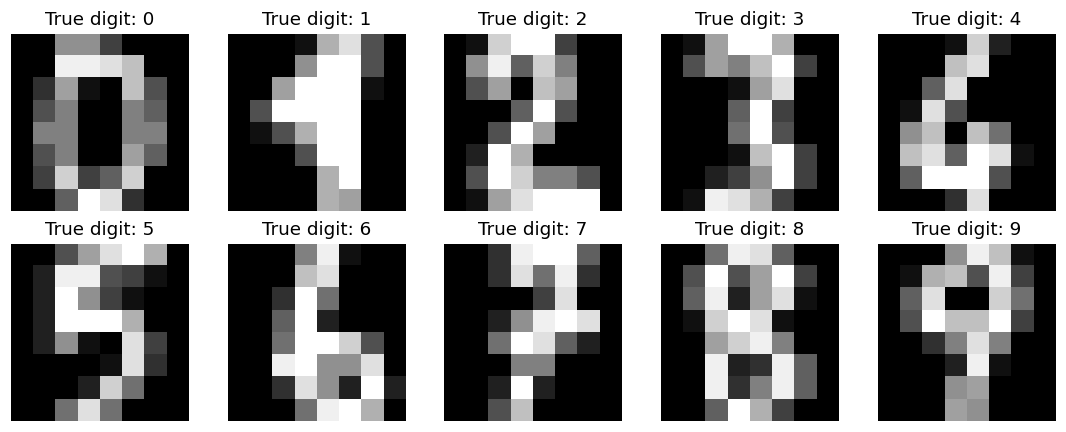

In [4]:
all_ids = np.arange(len(labels))
train_val_ids, test_ids = train_test_split(all_ids, test_size=0.2, stratify=labels, random_state=15)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25,
                                     stratify=labels[train_val_ids], random_state=15)
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
assert set(train_ids) | set(val_ids) | set(test_ids) == set(all_ids)
train_x, train_y = image_tensor(raw_images[train_ids]), torch.from_numpy(labels[train_ids])
val_x, val_y = image_tensor(raw_images[val_ids]), torch.from_numpy(labels[val_ids])
for name, ids in [('Training', train_ids), ('Validation', val_ids), ('Test', test_ids)]:
    print(name, len(ids), '| class counts:', np.bincount(labels[ids], minlength=10).tolist())
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    example = train_ids[np.flatnonzero(labels[train_ids] == digit)[0]]
    ax.imshow(raw_images[example], cmap='gray', vmin=0, vmax=16)
    ax.set_title(f'True digit: {digit}'); ax.axis('off')
plt.tight_layout(); plt.show()

## Build a small CNN whose dimensions we can explain

The model uses two 3 × 3 convolution blocks. Padding one preserves height and width before each 2 × 2 max pool halves them. ReLU makes the transformation nonlinear. The shapes for a batch of $N$ images are:

| Stage | Shape | Why it is here |
| --- | --- | --- |
| Input | $(N,1,8,8)$ | Preserve the pixel grid |
| Conv + ReLU | $(N,8,8,8)$ | Learn eight local response maps |
| Max pool | $(N,8,4,4)$ | Summarize neighboring responses |
| Conv + ReLU | $(N,16,4,4)$ | Combine earlier patterns into 16 maps |
| Max pool | $(N,16,2,2)$ | Keep a coarse spatial grid |
| Flatten | $(N,64)$ | $16\times2\times2=64$ features per image |
| Linear head | $(N,10)$ | Produce one logit per digit |

Unlike the miniature's global mean, flattening retains coarse location: whether evidence lies near the top or bottom can distinguish digits. This also means the head expects the chosen input size. There is no sigmoid or softmax layer at the end because multiclass cross-entropy consumes raw logits.

Count the parameters: the first convolution has $8(1\times3\times3+1)=80$; the second has $16(8\times3\times3+1)=1168$; the head has $10(64+1)=650$. Total: $80+1168+650=1898$. ReLU and pooling learn no parameters. We keep the model small and omit BatchNorm and dropout here to make the project easier to inspect; this is a design choice, not a rule against those components.

In [5]:
def make_model():
    return nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(64, 10),
    )

torch.manual_seed(150)
model = make_model()
with torch.no_grad():
    values = train_x[:4]
    for layer in model:
        values = layer(values)
        print(f'{type(layer).__name__:16s} -> {tuple(values.shape)}')
assert values.shape == (4, 10)
assert sum(p.numel() for p in model.parameters()) == 1898
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

Conv2d           -> (4, 8, 8, 8)
ReLU             -> (4, 8, 8, 8)
MaxPool2d        -> (4, 8, 4, 4)
Conv2d           -> (4, 16, 4, 4)
ReLU             -> (4, 16, 4, 4)
MaxPool2d        -> (4, 16, 2, 2)
Flatten          -> (4, 64)
Linear           -> (4, 10)
Trainable parameters: 1898


## Give the CNN a simpler comparison

Logistic regression receives the same normalized pixels but flattens each image into 64 values. For each digit it computes a weighted pixel sum plus an intercept, then uses competing class probabilities. It can exploit individual pixel locations but has no learned nonlinear hidden representation or local weight sharing.

Fit it on training images only, with a fixed regularization setting. It provides a meaningful comparison: a high CNN accuracy alone does not tell us whether convolution was needed on this small dataset. The two models share the data split and normalization, but this is not an exhaustive or equal-budget search over all their possible settings.

In [6]:
baseline = LogisticRegression(C=1.0, solver='lbfgs', max_iter=2000, random_state=15)
baseline.fit(train_x.flatten(1).numpy(), train_y.numpy())
assert baseline.n_iter_.max() < baseline.max_iter
np.testing.assert_array_equal(baseline.classes_, np.arange(10))
print('Baseline fitted using', len(train_x), 'training images.')

Baseline fitted using 1077 training images.


## Train repeatedly and let validation select the saved state

Each minibatch performs the same logic as the hand example: forward calculation, cross-entropy, backward derivatives, and a parameter update. With 1,077 training images and batch size 64, there are $\lceil1077/64\rceil=17$ updates per epoch. Forty fixed epochs give $17\times40=680$ updates.

`zero_grad` clears old accumulated gradients. `backward` calculates this batch's gradients; it does not change weights. Adam's `step` uses gradients and its internal running records to update parameters. We shuffle training indices each epoch and keep image–label pairs together.

After each epoch, evaluate both training and validation loss with the fixed current state. These curves are comparable because both are measured after the epoch, rather than averaging training losses from many different intermediate states. Save a deep copy whenever validation loss improves. We also consider the initial epoch-zero model. Reload the best saved state before any final test evaluation.

The test set cannot decide when to stop or which state to keep. A later training loss may be lower even when validation performance worsens; that is why the last epoch is not automatically the final model.

Updates: 680; selected epoch: 40; validation loss: 0.069247


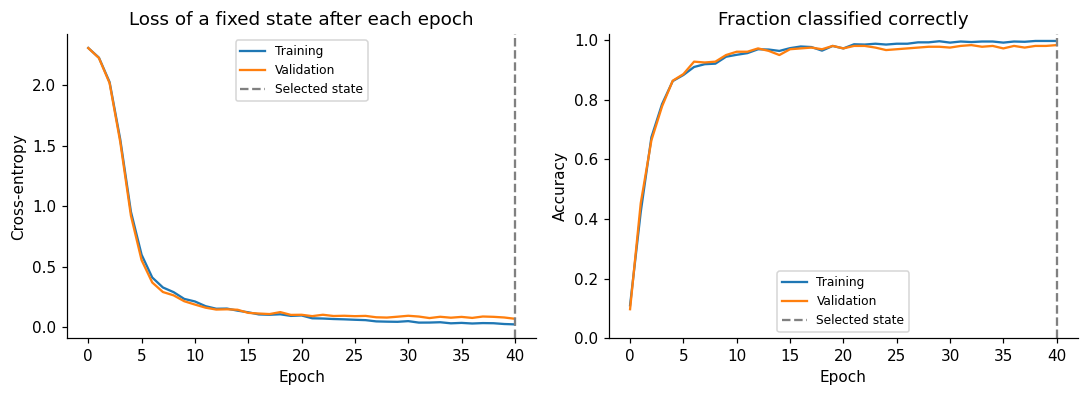

In [7]:
def evaluate(network, inputs, targets):
    network.eval()
    with torch.no_grad():
        logits = network(inputs)
        loss = F.cross_entropy(logits, targets).item()
        accuracy = (logits.argmax(1) == targets).float().mean().item()
    return loss, accuracy

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
shuffle = torch.Generator().manual_seed(151)
initial_train = evaluate(model, train_x, train_y)
initial_val = evaluate(model, val_x, val_y)
history = [(0, *initial_train, *initial_val)]
best_val_loss, best_epoch = initial_val[0], 0
best_state = copy.deepcopy(model.state_dict())
updates = 0
for epoch in range(1, 41):
    model.train()
    for ids in torch.randperm(len(train_x), generator=shuffle).split(64):
        optimizer.zero_grad(set_to_none=True)
        logits = model(train_x[ids])
        loss = F.cross_entropy(logits, train_y[ids])
        assert torch.isfinite(loss)
        loss.backward()
        optimizer.step()
        updates += 1
    train_loss, train_accuracy = evaluate(model, train_x, train_y)
    val_loss, val_accuracy = evaluate(model, val_x, val_y)
    history.append((epoch, train_loss, train_accuracy, val_loss, val_accuracy))
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
model.eval()
history = np.asarray(history)
assert updates == 680 and np.isfinite(history).all()
assert np.isclose(evaluate(model, val_x, val_y)[0], best_val_loss, rtol=1e-6)
print(f'Updates: {updates}; selected epoch: {best_epoch}; validation loss: {best_val_loss:.6f}')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].plot(history[:, 0], history[:, 1], label='Training')
axes[0].plot(history[:, 0], history[:, 3], label='Validation')
axes[0].set(ylabel='Cross-entropy', title='Loss of a fixed state after each epoch')
axes[1].plot(history[:, 0], history[:, 2], label='Training')
axes[1].plot(history[:, 0], history[:, 4], label='Validation')
axes[1].set(ylabel='Accuracy', ylim=(0, 1.02), title='Fraction classified correctly')
for ax in axes:
    ax.axvline(best_epoch, color='gray', linestyle='--', label='Selected state')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Open the test set after fixing the model

Accuracy is correct predictions divided by test images. Cross-entropy measures the probability assigned to the true class: $-\frac1N\sum_i\ln p_{i,y_i}$. Two models can make the same number of correct decisions but differ in their confidence and therefore in loss.

A confusion matrix has true classes on rows and predicted classes on columns. A value in row three, column eight counts threes predicted as eights. For one class, recall is true positives divided by all actual examples of that class; precision is true positives divided by all predictions of that class. If eight of ten actual twos are found and there is one false-positive two, recall is $8/10=0.8$, precision is $8/9\approx0.889$, and F1 is $2(8)/(2(8)+1+2)=16/19\approx0.842$.

Macro F1 averages class F1 values equally. These statistics add context to overall accuracy, but small per-class test counts make them variable. We evaluate each model's fixed predictions once, then reuse those predictions for plots and analysis.

Logistic regression: 345/360 correct (95.8%); log loss 0.185475; macro F1 0.9584
CNN: 350/360 correct (97.2%); log loss 0.104025; macro F1 0.9723
Digit | precision | recall | F1 | test count
    0 |     1.000 |  0.972 | 0.986 | 36
    1 |     0.947 |  1.000 | 0.973 | 36
    2 |     1.000 |  1.000 | 1.000 | 35
    3 |     1.000 |  0.973 | 0.986 | 37
    4 |     0.947 |  1.000 | 0.973 | 36
    5 |     0.972 |  0.946 | 0.959 | 37
    6 |     1.000 |  0.972 | 0.986 | 36
    7 |     1.000 |  1.000 | 1.000 | 36
    8 |     0.892 |  0.943 | 0.917 | 35
    9 |     0.971 |  0.917 | 0.943 | 36


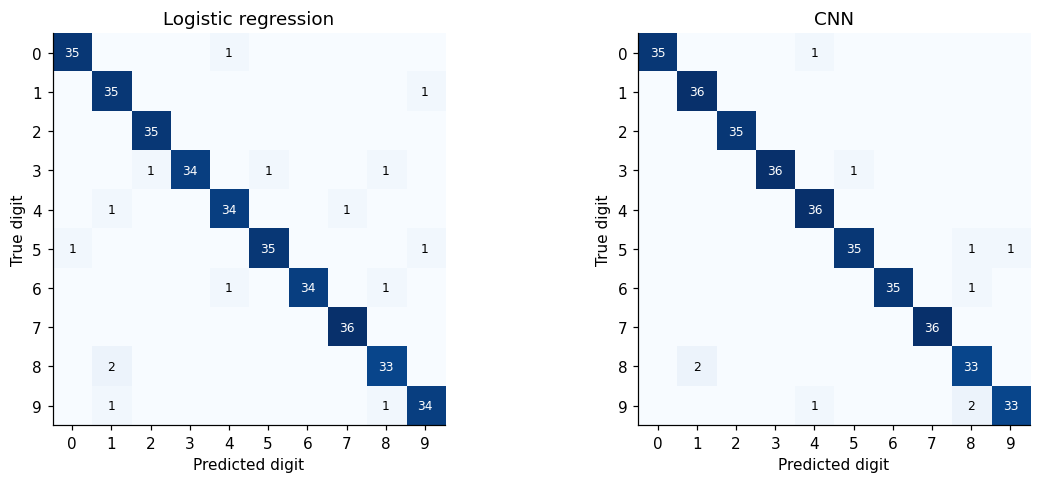

In [8]:
test_x = image_tensor(raw_images[test_ids])
test_y = torch.from_numpy(labels[test_ids])
with torch.no_grad():
    cnn_logits = model(test_x)
    cnn_probabilities = cnn_logits.softmax(1).numpy()
baseline_probabilities = baseline.predict_proba(test_x.flatten(1).numpy())
probability_sets = {'Logistic regression': baseline_probabilities, 'CNN': cnn_probabilities}
results, predictions_by_model, matrices = {}, {}, {}
for name, probabilities in probability_sets.items():
    assert np.isfinite(probabilities).all()
    np.testing.assert_allclose(probabilities.sum(1), 1., atol=1e-6)
    prediction = probabilities.argmax(1)
    predictions_by_model[name] = prediction
    correct = int((prediction == test_y.numpy()).sum())
    log_loss = float(-np.log(np.clip(probabilities[np.arange(len(test_y)), test_y.numpy()], 1e-12, 1)).mean())
    precision, recall, f1, support = precision_recall_fscore_support(
        test_y.numpy(), prediction, labels=np.arange(10), zero_division=0)
    results[name] = {'correct': correct, 'accuracy': correct/len(test_y),
                     'log_loss': log_loss, 'macro_f1': float(f1.mean())}
    matrices[name] = confusion_matrix(test_y.numpy(), prediction, labels=np.arange(10))
    assert matrices[name].sum() == len(test_y)
    print(f'{name}: {correct}/{len(test_y)} correct ({correct/len(test_y):.1%}); '
          f'log loss {log_loss:.6f}; macro F1 {f1.mean():.4f}')
    if name == 'CNN':
        print('Digit | precision | recall | F1 | test count')
        for digit in range(10):
            print(f'{digit:5d} | {precision[digit]:9.3f} | {recall[digit]:6.3f} | {f1[digit]:.3f} | {support[digit]}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
shared_max = max(matrix.max() for matrix in matrices.values())
for ax, (name, matrix) in zip(axes, matrices.items()):
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=shared_max)
    for r in range(10):
        for c in range(10):
            if matrix[r, c]:
                ax.text(c, r, str(matrix[r, c]), ha='center', va='center', fontsize=8,
                        color='white' if matrix[r, c] > shared_max/2 else 'black')
    ax.set(title=name, xlabel='Predicted digit', ylabel='True digit', xticks=range(10), yticks=range(10))
plt.tight_layout(); plt.show()

## Inspect mistakes without turning test images into training advice

Display up to eight mistakes in dataset order, showing the true label, prediction, and maximum probability. This is a descriptive look at a fixed model, not a chance to keep changing it until those test examples become correct. Further tuning would require fresh evaluation data.

A confident wrong answer is possible because softmax expresses relative scores over known classes; it does not certify that an image resembles the training distribution. Blur, new writing styles, reversed intensity, off-center crops, or multiple digits can change behavior. A model trained on one digit per image has no built-in “unknown image” output.

Data augmentation can help when it preserves labels, but it must be chosen for the task and applied only during training. Arbitrary flips or rotations may change digit meaning, so this introductory run uses no augmentation. More complex preprocessing should be evaluated as part of the full prediction recipe.

Held-out mistakes: 10 | displayed: 8


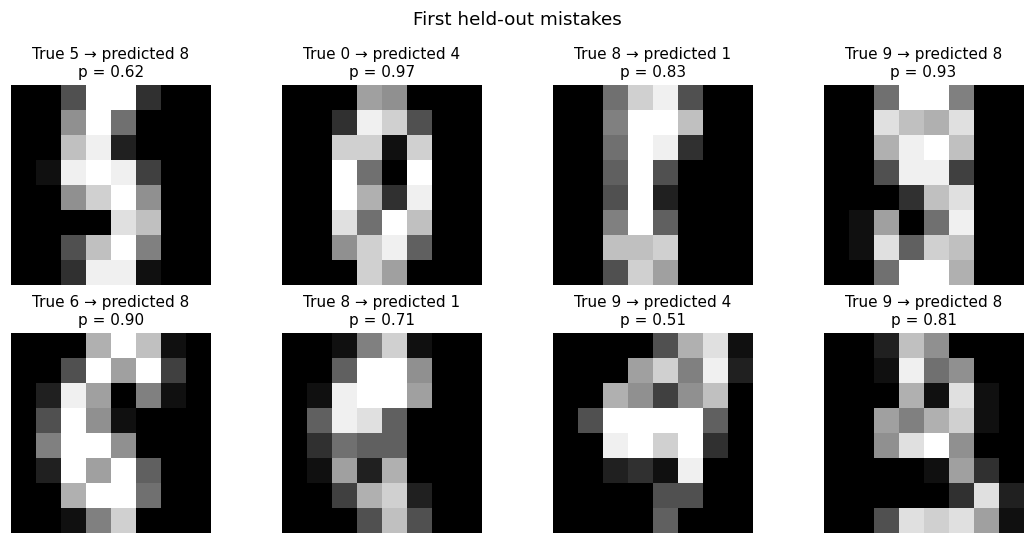

In [9]:
cnn_predictions = predictions_by_model['CNN']
wrong = np.flatnonzero(cnn_predictions != test_y.numpy())
chosen = wrong[:8] if len(wrong) else np.arange(min(8, len(test_y)))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax in axes.flat:
    ax.axis('off')
for ax, index in zip(axes.flat, chosen):
    ax.imshow(raw_images[test_ids[index]], cmap='gray', vmin=0, vmax=16)
    confidence = cnn_probabilities[index].max()
    ax.set_title(f'True {test_y[index].item()} → predicted {cnn_predictions[index]}\np = {confidence:.2f}', fontsize=10)
fig.suptitle('First held-out mistakes' if len(wrong) else 'No errors in this split; showing held-out examples')
plt.tight_layout(); plt.show()
print('Held-out mistakes:', len(wrong), '| displayed:', len(chosen))

## Trace a real prediction through the trained model

The actual network has too many multiplications to print all of them usefully. We can still expose the whole chain for one fixed test image: its normalized 8 × 8 input, one filter calculation, every intermediate shape, ten final logits, and the top-three class probabilities.

The first convolution's top-left score is the sum of nine pixel–weight products plus its bias. Because padding is one, its patch includes zeros above and left of the image. We explicitly compute this dot product and compare it to the layer's output. ReLU then clips negative scores to zero, pooling chooses local maxima, the second convolution combines channels, and the head computes $z_j=\sum_{k=1}^{64}W_{jk}h_k+b_j$ for each digit $j$.

We verify all ten head logits with matrix multiplication and independently normalize exponentials to reproduce the probabilities. This links a real prediction to the hand example: the same operations now use weights learned from data. A feature-map picture shows responses, not a complete causal explanation of why the network chose its class.

Normalized input:
 tensor([[0.0000, 0.0000, 0.8750, 1.0000, 1.0000, 1.0000, 0.1250, 0.0000],
        [0.0000, 0.4375, 1.0000, 0.3125, 0.0625, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8750, 0.8125, 0.4375, 0.1875, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.7500, 0.8125, 1.0000, 0.5625, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3750, 0.9375, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.5625, 0.8750, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.3125, 0.8750, 1.0000, 0.1875, 0.0000, 0.0000],
        [0.0000, 0.0625, 0.9375, 0.6875, 0.2500, 0.0000, 0.0000, 0.0000]])
Padded patch:
 tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4375]])
First filter:
 tensor([[ 0.2253, -0.1729, -1.0055],
        [ 0.1662,  0.7206, -0.1158],
        [-0.8242, -0.0686,  0.6460]], requires_grad=True)
Pixel × weight contributions:
 tensor([[0.0000, -0.0000, -0.0000],
        [0.0000, 0.0000, -0.0000],
        [-0.0000, -0.

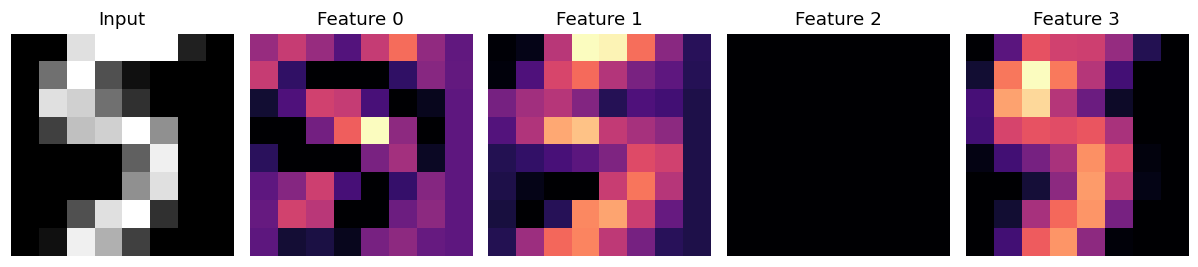

In [10]:
example_index = 0
one_image = test_x[example_index:example_index+1]
with torch.no_grad():
    first_scores = model[0](one_image)
    top_left_patch = F.pad(one_image, (1, 1, 1, 1))[0, 0, :3, :3]
    filter_zero = model[0].weight[0, 0]
    contributions = top_left_patch * filter_zero
    manual_first = contributions.sum() + model[0].bias[0]
    torch.testing.assert_close(manual_first, first_scores[0, 0, 0, 0])
    features = model[:7](one_image)
    manual_logits = features @ model[-1].weight.T + model[-1].bias
    torch.testing.assert_close(manual_logits, cnn_logits[example_index:example_index+1])
    shifted = manual_logits - manual_logits.max(1, keepdim=True).values
    exp_values = shifted.exp()
    manual_probabilities = exp_values / exp_values.sum(1, keepdim=True)
    torch.testing.assert_close(manual_probabilities, torch.from_numpy(cnn_probabilities[example_index:example_index+1]))
    top_probability, top_class = manual_probabilities[0].topk(3)
print('Normalized input:\n', one_image[0, 0])
print('Padded patch:\n', top_left_patch)
print('First filter:\n', filter_zero)
print('Pixel × weight contributions:\n', contributions)
print('First bias:', model[0].bias[0].item(), '| summed score:', manual_first.item())
print('Flattened hidden shape:', tuple(features.shape))
print('All class logits:', np.round(manual_logits.numpy()[0], 4).tolist())
print('Actual digit:', test_y[example_index].item())
print('Top three:', [(class_names[c], round(p, 4)) for c, p in zip(top_class.tolist(), top_probability.tolist())])
fig, axes = plt.subplots(1, 5, figsize=(11, 3))
axes[0].imshow(one_image[0, 0], cmap='gray', vmin=0, vmax=1); axes[0].set_title('Input')
for channel, ax in enumerate(axes[1:]):
    ax.imshow(first_scores[0, channel].relu(), cmap='magma'); ax.set_title(f'Feature {channel}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## Save the complete recipe and reproduce the same prediction

A saved network needs more than weights: its architecture, pixel scale, image shape, channel convention, and class mapping give those weights meaning. At inference we apply the same fixed scaling, call `eval()`, and run a forward pass without gradient recording. No target label or optimizer is needed to make a prediction.

The companion saves a bundle in a temporary directory, restores it into a fresh model, and confirms identical probabilities. The temporary file is then removed, so running the lesson does not leave checkpoints around. A production application would choose a persistent destination and a preprocessing pipeline appropriate to its actual image source.

The helper accepts a batch shaped `(N, 8, 8)` with finite values between zero and 16, using the bundled dataset's brightness convention. It does not resize arbitrary photographs or detect where their digits are. Those would be separate, testable processing steps.

In [11]:
def predict_images(network, raw_batch):
    inputs = image_tensor(raw_batch)
    network.eval()
    with torch.no_grad():
        return network(inputs).softmax(1).numpy()

example_raw = raw_images[test_ids[:3]]
expected_probabilities = predict_images(model, example_raw)
np.testing.assert_allclose(expected_probabilities, cnn_probabilities[:3], atol=1e-6)
bundle = {
    'state_dict': copy.deepcopy(model.state_dict()),
    'architecture': 'conv1_8_pool_conv8_16_pool_flat64_linear10_v1',
    'image_shape': [8, 8], 'channels': 1, 'pixel_divisor': 16.0,
    'class_names': class_names, 'selected_epoch': best_epoch,
}
with tempfile.TemporaryDirectory() as directory:
    checkpoint = Path(directory) / 'digit_cnn.pt'
    torch.save(bundle, checkpoint)
    restored = torch.load(checkpoint, map_location='cpu', weights_only=True)
    assert restored['architecture'] == bundle['architecture']
    assert restored['image_shape'] == [8, 8] and restored['channels'] == 1
    assert restored['pixel_divisor'] == 16.0 and restored['class_names'] == class_names
    restored_model = make_model()
    restored_model.load_state_dict(restored['state_dict'])
    actual_probabilities = predict_images(restored_model, example_raw)
    np.testing.assert_allclose(actual_probabilities, expected_probabilities, atol=1e-7)
# Ensure the public input contract rejects incompatible images.
for invalid in [np.zeros((8, 8)), np.full((1, 8, 8), 17.), np.full((1, 8, 8), np.nan)]:
    try:
        image_tensor(invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid input was accepted.')
print('Saved and restored probabilities match. Temporary checkpoint removed.')

Saved and restored probabilities match. Temporary checkpoint removed.


## Read the saved reference run

Validation selected epoch 40 of 40, with validation cross-entropy 0.069247. The selected model was then evaluated on 360 held-out images.

| Model | Correct | Accuracy | Cross-entropy | Macro F1 |
| --- | --- | --- | --- | --- |
| Logistic regression | 345/360 | 95.8% | 0.185475 | 0.9584 |
| CNN | 350/360 | 97.2% | 0.104025 | 0.9723 |

These are observed results for one fixed image split, not guaranteed scores on another run or a different source of handwriting. The data do not provide writer groups for this evaluation. Neither model was tuned using these test results. The save/restore check reproduced the same probabilities.

## What this project establishes

The CNN learns a mapping from normalized pixel grids to ten digit scores. Shared filters learn local evidence, nonlinear layers combine it, and a supervised loss adjusts every trainable stage. The hand example shows why a gradient update can help; the real project measures what repeated learning achieves on held-out images.

The baseline comparison, confusion matrices, and error images determine how to interpret the run. A CNN may outperform a linear baseline on a split, but that is not a universal ranking or proof of writer-independent performance. Saved probabilities are not guaranteed calibrated confidence. Generalization to another source of images requires representative data and separate evaluation.

The practical logic is connected end to end: define the input and target, separate the data roles, choose an architecture, calculate a loss, update from training examples, select using validation, evaluate once, and preserve the recipe for future predictions.